## Spark Lab: Open Air Quality data set, reading data from S3

In [44]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

### Download and initialize Spark

In [2]:
# Install OpenJDK 8 (Spark still works well with Java 8, though Java 11 is also supported)
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

# Download Spark 3.5.1 with Hadoop 3.3
!wget -q https://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz
!tar -xvf spark-3.5.1-bin-hadoop3.tgz > /dev/null

# Install findspark and seaborn quietly
!pip install -q findspark > /dev/null
!pip install seaborn > /dev/null

!wget -q https://repo1.maven.org/maven2/org/apache/hadoop/hadoop-aws/3.3.4/hadoop-aws-3.3.4.jar -P /content/spark-3.5.1-bin-hadoop3/jars/
!wget -q https://repo1.maven.org/maven2/com/amazonaws/aws-java-sdk-bundle/1.12.262/aws-java-sdk-bundle-1.12.262.jar -P /content/spark-3.5.1-bin-hadoop3/jars/

# Install pyngrok (for exposing Spark UI)
!pip install pyngrok > /dev/null

In [3]:
# Set up environment variables for Spark
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.1-bin-hadoop3"

# Initialize findspark and start a SparkSession
import findspark
findspark.init()
from pyspark.sql import SparkSession

# Create SparkSession
spark = SparkSession.builder \
    .appName("UpdatedSparkApp") \
    .getOrCreate()

# Verify the Spark version
print("Spark Version:", spark.version)

Spark Version: 3.5.1


In [ ]:
# Optional: use ngrok to expose Spark GUI (requires ngrok account)
from pyngrok import ngrok, conf
import getpass

print("Enter your authtoken, which can be copied "
"from https://dashboard.ngrok.com/get-started/your-authtoken")
conf.get_default().auth_token = getpass.getpass()

ui_port = 4040
public_url = ngrok.connect(ui_port).public_url
print(f" * ngrok tunnel \"{public_url}\" -> \"http://127.0.0.1:{ui_port}\"")

Enter your authtoken, which can be copied from https://dashboard.ngrok.com/get-started/your-authtoken


KeyboardInterrupt: Interrupted by user

### Configure AWS credentials


**Important**: you need to copy your AWS credentials to file named `aws_credentials`. Format:
```
aws_access_key_id=<access_key>
aws_secret_access_key=<secret_key>
aws_session_token=<session_token>
```
In AWS Academy you can find your credentials under AWS Details -> AWS CLI -> Show button

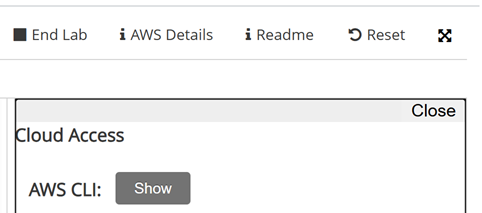

In [4]:
# Read credentials from the file
credentials = {}
with open("/content/aws_credentials", "r") as f:
    for line in f:
        key, value = line.strip().split("=", 1)
        credentials[key] = value

# Extract credentials
AWS_ACCESS_KEY = credentials["aws_access_key_id"]
AWS_SECRET_KEY = credentials["aws_secret_access_key"]
AWS_SESSION_TOKEN = credentials["aws_session_token"]

In [5]:
spark.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.access.key", AWS_ACCESS_KEY)
spark.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.secret.key", AWS_SECRET_KEY)
spark.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.session.token", AWS_SESSION_TOKEN)
# Additional S3A configuration (optional but recommended)
# spark.sparkContext._jsc.hadoopConfiguration().set("fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")

### Reading OpenAQ data from AWS S3

OpenAQ project: https://openaq.org/

Registry of AWS Open Data: https://registry.opendata.aws/openaq/

S3 bucket structure: https://docs.openaq.org/aws/about

Now we can read a small sample of data:

In [6]:
smog_df = spark \
    .read \
    .format("csv") \
    .option("compression", "gzip") \
    .option("header", True) \
    .load("s3a://openaq-data-archive/records/csv.gz/locationid=100*/year=2022/month=05/location-100*-2022050*.csv.gz")

    # Data from one day in one location:
    #.load("s3a://openaq-data-archive/records/csv.gz/locationid=2178/year=2022/month=05/location-2178-20220503.csv.gz")

    # Data from May 2022 from multiple locations:
    #.load("s3a://openaq-data-archive/records/csv.gz/locationid=10*/year=2022/month=05/*.csv.gz")


In [7]:
smog_df.count()

1500

In [8]:
smog_df.printSchema()

root
 |-- location_id: string (nullable = true)
 |-- sensors_id: string (nullable = true)
 |-- location: string (nullable = true)
 |-- datetime: string (nullable = true)
 |-- lat: string (nullable = true)
 |-- lon: string (nullable = true)
 |-- parameter: string (nullable = true)
 |-- units: string (nullable = true)
 |-- value: string (nullable = true)



In [9]:
# Sample 1% of the data and show 10 records
smog_df.sample(fraction=0.01).limit(10).show(truncate=False)

+-----------+----------+--------------------------+-------------------------+---------+----------+---------+-----+------+
|location_id|sensors_id|location                  |datetime                 |lat      |lon       |parameter|units|value |
+-----------+----------+--------------------------+-------------------------+---------+----------+---------+-----+------+
|100        |162       |Badhoevedorp-Sloterweg-100|2022-05-07T04:00:00+02:00|52.334   |4.77401   |co       |µg/m³|-999.0|
|100        |4231      |Badhoevedorp-Sloterweg-100|2022-05-03T03:00:00+02:00|52.334   |4.77401   |pm10     |µg/m³|22.3  |
|100        |4147      |Badhoevedorp-Sloterweg-100|2022-05-09T17:00:00+02:00|52.334   |4.77401   |pm25     |µg/m³|-999.0|
|1003       |1807      |Padonia-1003              |2022-05-03T09:00:00-04:00|39.462002|-76.631599|pm25     |µg/m³|16.0  |
|1003       |1807      |Padonia-1003              |2022-05-03T19:00:00-04:00|39.462002|-76.631599|pm25     |µg/m³|6.0   |
|1003       |1807      |

### Using extended locations data

Data in the S3 bucket contains only a few necessary fields -- parameter readings and a limited information about sensor locations.

Additional information are available through OpenAQ API: https://api.openaq.org/

File `openaq_locations.json` contains extended information about locations which was downloaded using this REST API.

Data from this file joined with data in S3 can be used for more advanced queries.

For start let's locate all locations in Kraków.

In [10]:
from pyspark.sql.functions import col, asc, desc, max

In [11]:
# Download and upack OpenAQ locations data file
!wget https://github.com/dice-dydakt/datasets/raw/refs/heads/main/openaq_locations.json.gz && gunzip -f openaq_locations.json.gz

--2025-12-17 20:16:25--  https://github.com/dice-dydakt/datasets/raw/refs/heads/main/openaq_locations.json.gz
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/dice-dydakt/datasets/refs/heads/main/openaq_locations.json.gz [following]
--2025-12-17 20:16:26--  https://raw.githubusercontent.com/dice-dydakt/datasets/refs/heads/main/openaq_locations.json.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1834423 (1.7M) [application/octet-stream]
Saving to: ‘openaq_locations.json.gz’

openaq_locations.js 100%[===================>]   1.75M  --.-KB/s    in 0.07s   

2025-12-17 20:16:26 (26.2 MB/s) - ‘open

In [12]:
# Let's load the file as Spark dataframe and print the schema
# Note: the file is small, so we could have used Pandas for this
# However, having a spark dataframe allows joining it with smog_df

df = spark.read.option("multiLine", True).json("openaq_locations.json")
display(df.select("id").distinct().count())
df.printSchema()

18798

root
 |-- bounds: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- coordinates: struct (nullable = true)
 |    |-- latitude: double (nullable = true)
 |    |-- longitude: double (nullable = true)
 |-- country: struct (nullable = true)
 |    |-- code: string (nullable = true)
 |    |-- id: long (nullable = true)
 |    |-- name: string (nullable = true)
 |-- datetimeFirst: struct (nullable = true)
 |    |-- local: string (nullable = true)
 |    |-- utc: string (nullable = true)
 |-- datetimeLast: struct (nullable = true)
 |    |-- local: string (nullable = true)
 |    |-- utc: string (nullable = true)
 |-- distance: string (nullable = true)
 |-- id: long (nullable = true)
 |-- instruments: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- id: long (nullable = true)
 |    |    |-- name: string (nullable = true)
 |-- isMobile: boolean (nullable = true)
 |-- isMonitor: boolean (nullable = true)
 |-- licenses: array (nullable =

In [13]:
# Select some useful columns and flatten the structure
locations_df = df.select(
    "id",
    "name",
    "timezone",
    df["country.code"].alias("country_code"),
    df["country.name"].alias("country_name"),
    df.coordinates.latitude.alias("latitude"),  # this way of selecting a nested column works too
    df.coordinates.longitude.alias("longitude")
)

# Show a sample of the flattened DataFrame
locations_df.sample(fraction=0.01).show(truncate=False)
locations_df.printSchema()

+----+---------------------------+-------------------+------------+-------------+------------------+-----------+
|id  |name                       |timezone           |country_code|country_name |latitude          |longitude  |
+----+---------------------------+-------------------+------------+-------------+------------------+-----------+
|42  |SPARTAN - Ilorin University|Africa/Lagos       |NG          |Nigeria      |8.484             |4.675      |
|64  |Mustang Bayou C619         |America/Chicago    |US          |United States|29.308562         |-95.19991  |
|433 |Polson-MT                  |America/Denver     |US          |United States|47.6925           |-114.0122  |
|574 |Fairhaven2                 |America/New_York   |US          |United States|41.6454           |-70.898    |
|592 |Albion Park Sth            |Australia/Sydney   |AU          |Australia    |-34.5805556       |150.7816667|
|894 |PUBLIC HEALTH              |America/Chicago    |US          |United States|41.9767        

In [14]:
# How many sensor locations in Poland are there?
locations_df.filter(col('country_code')=='PL').count()

363

In [15]:
# Filter out only those locations which are in Kraków
krak_locations_df = locations_df.filter(locations_df.country_code == 'PL').select('name', 'id').filter(col('name').contains('Krak'))
krak_locations_df.toPandas()

,name,id
0,"Kraków, ul. Bujaka",7239
1,"Piotrków Trybunalski, ul. Krakowskie Przedmieście",7251
2,"Kraków, ul. Złoty Róg",9464
3,"Kraków, ul. Dietla",9465
4,"Kraków, os. Wadów",9546
5,"Kraków, os. Swoszowice",9550
6,"Kraków, os. Piastów",9555
7,"Kraków, ul. Bulwarowa",10516
8,"Kraków, Aleja Krasińskiego",10752
9,"Kraków, ul. Kamieńskiego",2658600


In [16]:
# Construct a list of file names for the locations in Krakow

# Copy a dataframe column into a Python list
krak_location_ids = krak_locations_df.select("id").rdd.flatMap(lambda x: x).collect()

# Remove two locations:
krak_location_ids.remove(2658600) # doesn't work
krak_location_ids.remove(7251)    # not Kraków

# Construct file paths to read data from May and June 2022 for all these locations
s3_paths = [
    f"s3a://openaq-data-archive/records/csv.gz/locationid={loc_id}/year=2022/month={{05,06}}/*.csv.gz"
    for loc_id in krak_location_ids
]
s3_paths

['s3a://openaq-data-archive/records/csv.gz/locationid=7239/year=2022/month={05,06}/*.csv.gz',
 's3a://openaq-data-archive/records/csv.gz/locationid=9464/year=2022/month={05,06}/*.csv.gz',
 's3a://openaq-data-archive/records/csv.gz/locationid=9465/year=2022/month={05,06}/*.csv.gz',
 's3a://openaq-data-archive/records/csv.gz/locationid=9546/year=2022/month={05,06}/*.csv.gz',
 's3a://openaq-data-archive/records/csv.gz/locationid=9550/year=2022/month={05,06}/*.csv.gz',
 's3a://openaq-data-archive/records/csv.gz/locationid=9555/year=2022/month={05,06}/*.csv.gz',
 's3a://openaq-data-archive/records/csv.gz/locationid=10516/year=2022/month={05,06}/*.csv.gz',
 's3a://openaq-data-archive/records/csv.gz/locationid=10752/year=2022/month={05,06}/*.csv.gz']

In [17]:
# Read only data from these files!
smog_df = spark \
    .read \
    .format("csv") \
    .option("compression", "gzip") \
    .option("header", True) \
    .load(s3_paths)

In [18]:
smog_df = smog_df.withColumn("value", smog_df.value.cast('double'))

### Effect of caching

In [19]:
# Uncomment and run this, then run queries again (multiple times) and observe their execution times
# Further queries on smog_df will run much faster when we cache this data set in memory
smog_df.cache()

DataFrame[location_id: string, sensors_id: string, location: string, datetime: string, lat: string, lon: string, parameter: string, units: string, value: double]

In [ ]:
# use this to remove smog_df from cache
# smog_df.unpersist()

In [23]:
# Run multiple times and observe the cell execution time - with and without caching
smog_df.count()

11643

### Example queries

In [24]:
smog_df.select('parameter').distinct().show()

+---------+
|parameter|
+---------+
|       bc|
|      so2|
|       co|
|     pm10|
|      no2|
|     pm25|
|       o3|
+---------+



In [25]:
# Analyze this query - what is its purpose?
max_pm10 = smog_df.filter(col('parameter')=='pm10')\
            .filter(col('value')>0.0)\
            .groupby('location').agg(max('value').alias('max_pm10'))\
            .sort(desc('max_pm10'))

max_pm10.limit(100).show(truncate=False)

+--------------------------------+--------+
|location                        |max_pm10|
+--------------------------------+--------+
|Kraków, os. Piastów-9555        |123.735 |
|Kraków, ul. Bulwarowa-10516     |92.1151 |
|Kraków, Aleja Krasińskiego-10752|90.8715 |
|Kraków, os. Wadów-9546          |88.2342 |
|Kraków, ul. Dietla-9465         |83.4921 |
|Kraków, ul. Złoty Róg-9464      |72.5665 |
|Kraków, ul. Bujaka-7239         |62.8579 |
|Kraków, os. Swoszowice-9550     |50.1133 |
+--------------------------------+--------+



In [26]:
max_pm10.printSchema()

root
 |-- location: string (nullable = true)
 |-- max_pm10: double (nullable = true)



<Axes: ylabel='location'>

<Figure size 640x480 with 0 Axes>

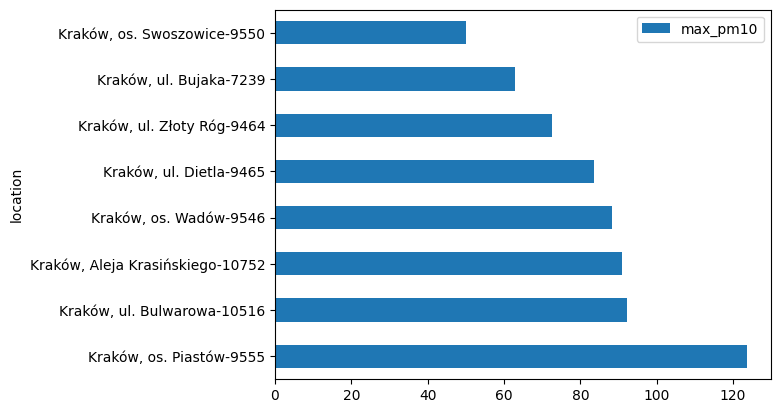

In [27]:
plt.figure()
max_pm10.limit(10).toPandas().plot.barh(x='location')

### Zadanie 1

[1p.] Wczytaj dane dla kilkudziesięciu lokalizacji w Polsce z dłuższego okresu (na ile pozwoli pamięć). Stwórz zapytanie, które dla każdej lokalizacji oblicza średnie stężenie wybranego parametru dla każdej godziny dnia (0-1, 1-2, ..., 23-24) i znajduje godzinę, w których średnia ta była najwyższa.

In [32]:
from pyspark.sql.functions import col, hour, avg, desc, row_number, dayofweek
from pyspark.sql.window import Window

def get_valid_monthly_paths(loc_ids, year, months):
    sc = spark.sparkContext
    fs = sc._jvm.org.apache.hadoop.fs.FileSystem.get(
        sc._jvm.java.net.URI("s3a://openaq-data-archive/"),
        sc._jsc.hadoopConfiguration()
    )
    Path = sc._jvm.org.apache.hadoop.fs.Path

    valid_paths = []
    for lid in loc_ids:
        for m in months:
            p = f"s3a://openaq-data-archive/records/csv.gz/locationid={lid}/year={year}/month={m}/"
            try:
                if fs.exists(Path(p)):
                    valid_paths.append(p)
            except:
                pass
    return valid_paths

In [33]:
pl_locs = locations_df.filter(col("country.code") == "PL") \
    .filter(col("datetimeLast.utc") >= "2023-01-01") \
    .select("id", "name") \
    .distinct() \
    .limit(40) \
    .collect()

pl_ids = [row.id for row in pl_locs]
data_paths = get_valid_monthly_paths(pl_ids, "2023", ["01", "02", "03"])
df_raw = spark.read.option("header", "true").csv(data_paths)
df_clean = df_raw.withColumn("value", col("value").cast("double")) \
                 .withColumn("datetime", col("datetime").cast("timestamp"))

df_joined = df_clean.join(locations_df, df_clean.location_id == locations_df.id)

hourly_avg = df_joined.filter(col("parameter") == "pm10") \
    .groupBy("name", hour("datetime").alias("hour")) \
    .agg(avg("value").alias("avg_concentration"))

window_spec = Window.partitionBy("name").orderBy(desc("avg_concentration"))

result_task1 = hourly_avg.withColumn("rank", row_number().over(window_spec)) \
    .filter(col("rank") == 1) \
    .select("name", "hour", "avg_concentration") \
    .orderBy(desc("avg_concentration"))

result_task1.show(10, truncate=False)

+------------------------------------+----+------------------+
|name                                |hour|avg_concentration |
+------------------------------------+----+------------------+
|Włocławek, ul. Kaliska              |6   |266.2085106382979 |
|Sucha Beskidzka, ul. Nieszczyńskiej |20  |61.519974166666664|
|Nowy Targ, al. Tysiąclecia          |19  |52.16419999999998 |
|Olkusz, ul. Cegielniana             |20  |48.61847916666667 |
|Muszyna, Lodowisko                  |22  |42.88895905660377 |
|Bielsko-Biała, ul. Kossak-Szczuckiej|21  |39.26876021739131 |
|Skawina, os. Ogrody                 |21  |36.94988608695653 |
|Rzeszów, ul. Starzyńskiego          |19  |36.18379125000001 |
|Połaniec, ul. Ruszczańska           |21  |36.02975000000001 |
|Katowice, ul. Plebiscytowa/A4       |22  |35.5885           |
+------------------------------------+----+------------------+
only showing top 10 rows



### Zadanie 2

[1p.] Dla każdej lokalizacji znajdź najwyższe średnie stężenie wybranego parametru w danym dniu tygodnia (Pn-Nd) w godzinach 8-20. Wyniki przedstaw posortowane po lokalizacji, a następnie malejąco po obliczonym stężeniu. Stwórz wizualizację podobną do załączonego przykładu.

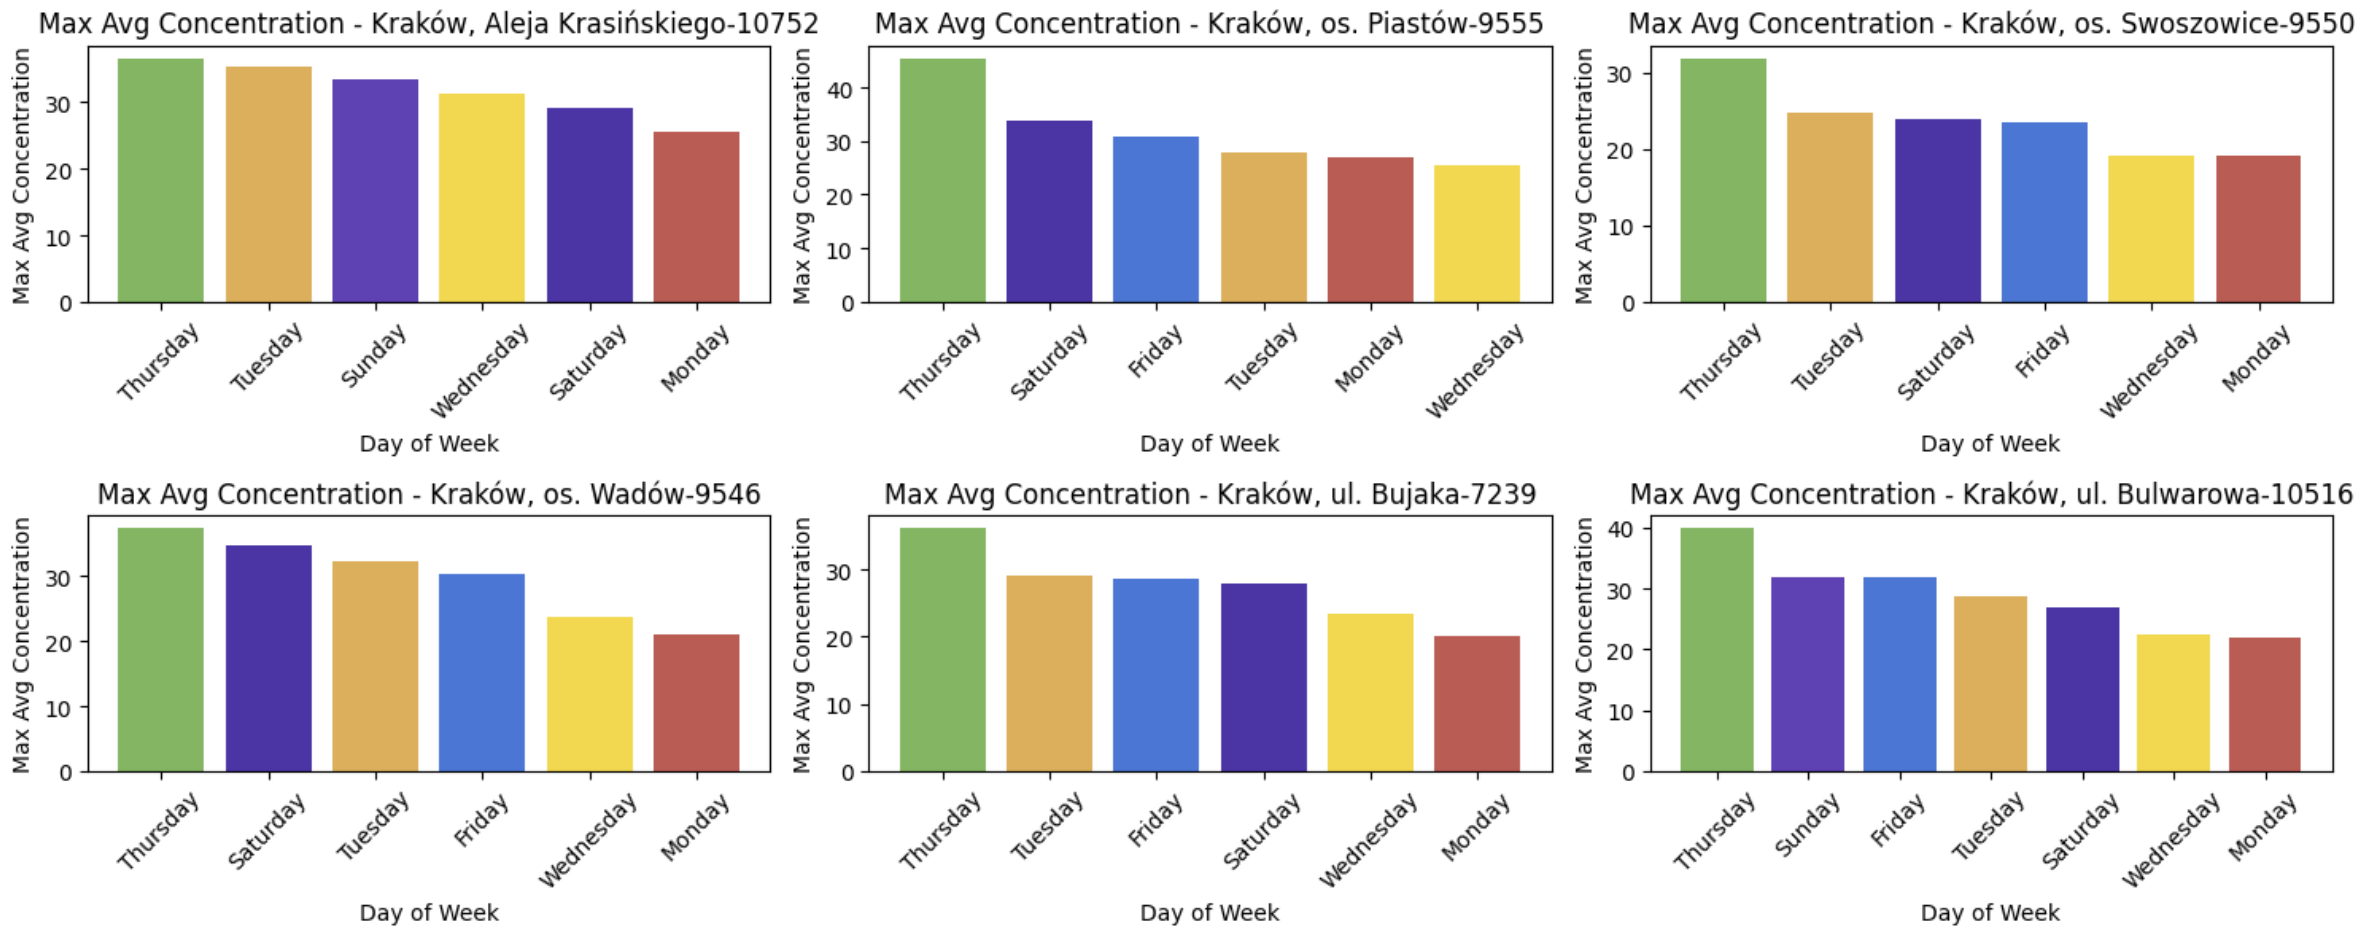

In [34]:
task2_df = df_joined.filter((hour("datetime") >= 8) & (hour("datetime") <= 20)) \
                    .filter(col("parameter") == "pm10")

task2_agg = task2_df.groupBy("name", dayofweek("datetime").alias("dow")) \
                    .agg(avg("value").alias("avg_value"))

window_spec = Window.partitionBy("name").orderBy(desc("avg_value"))

task2_result = task2_agg.withColumn("rank", row_number().over(window_spec)) \
                        .filter(col("rank") == 1) \
                        .select("name", "dow", "avg_value") \
                        .orderBy("name", desc("avg_value"))

task2_result.show(truncate=False)

+------------------------------------+---+------------------+
|name                                |dow|avg_value         |
+------------------------------------+---+------------------+
|Bielsko-Biała, ul. Kossak-Szczuckiej|3  |33.289163095238095|
|Brzeg, ul. Poprzeczna               |6  |32.63248186440678 |
|Dzierżoniów, ul. Piłsudskiego       |3  |30.0561641346154  |
|Dąbrowa Górnicza, ul. Tysiąclecia   |2  |28.959785714285722|
|Dębica, ul.Grottgera                |2  |24.28966538461539 |
|Elbląg, ul. Bażyńskiego             |5  |22.16338660194173 |
|Gajew, Ujęcie Wody                  |5  |28.78640776699029 |
|Gdańsk, ul. Leczkowa                |5  |23.229543823529415|
|Goczałkowice Zdrój, ul. Parkowa     |2  |18.657969230769236|
|Gołuchów, Ujęcie Wody               |2  |20.127384615384617|
|Guty Duże                           |5  |24.625555555555554|
|Katowice, ul. Plebiscytowa/A4       |2  |34.68085641025641 |
|Kielce, ul. Jurajska                |4  |24.162972972972977|
|Kraków,

Plotting weekly profiles for: ['Nowy Targ, al. Tysiąclecia ', 'Sucha Beskidzka, ul. Nieszczyńskiej', 'Skawina, os. Ogrody', 'Muszyna, Lodowisko', 'Katowice, ul. Plebiscytowa/A4', 'Szamotuły, ul. Kołłątaja']


<Figure size 640x480 with 0 Axes>

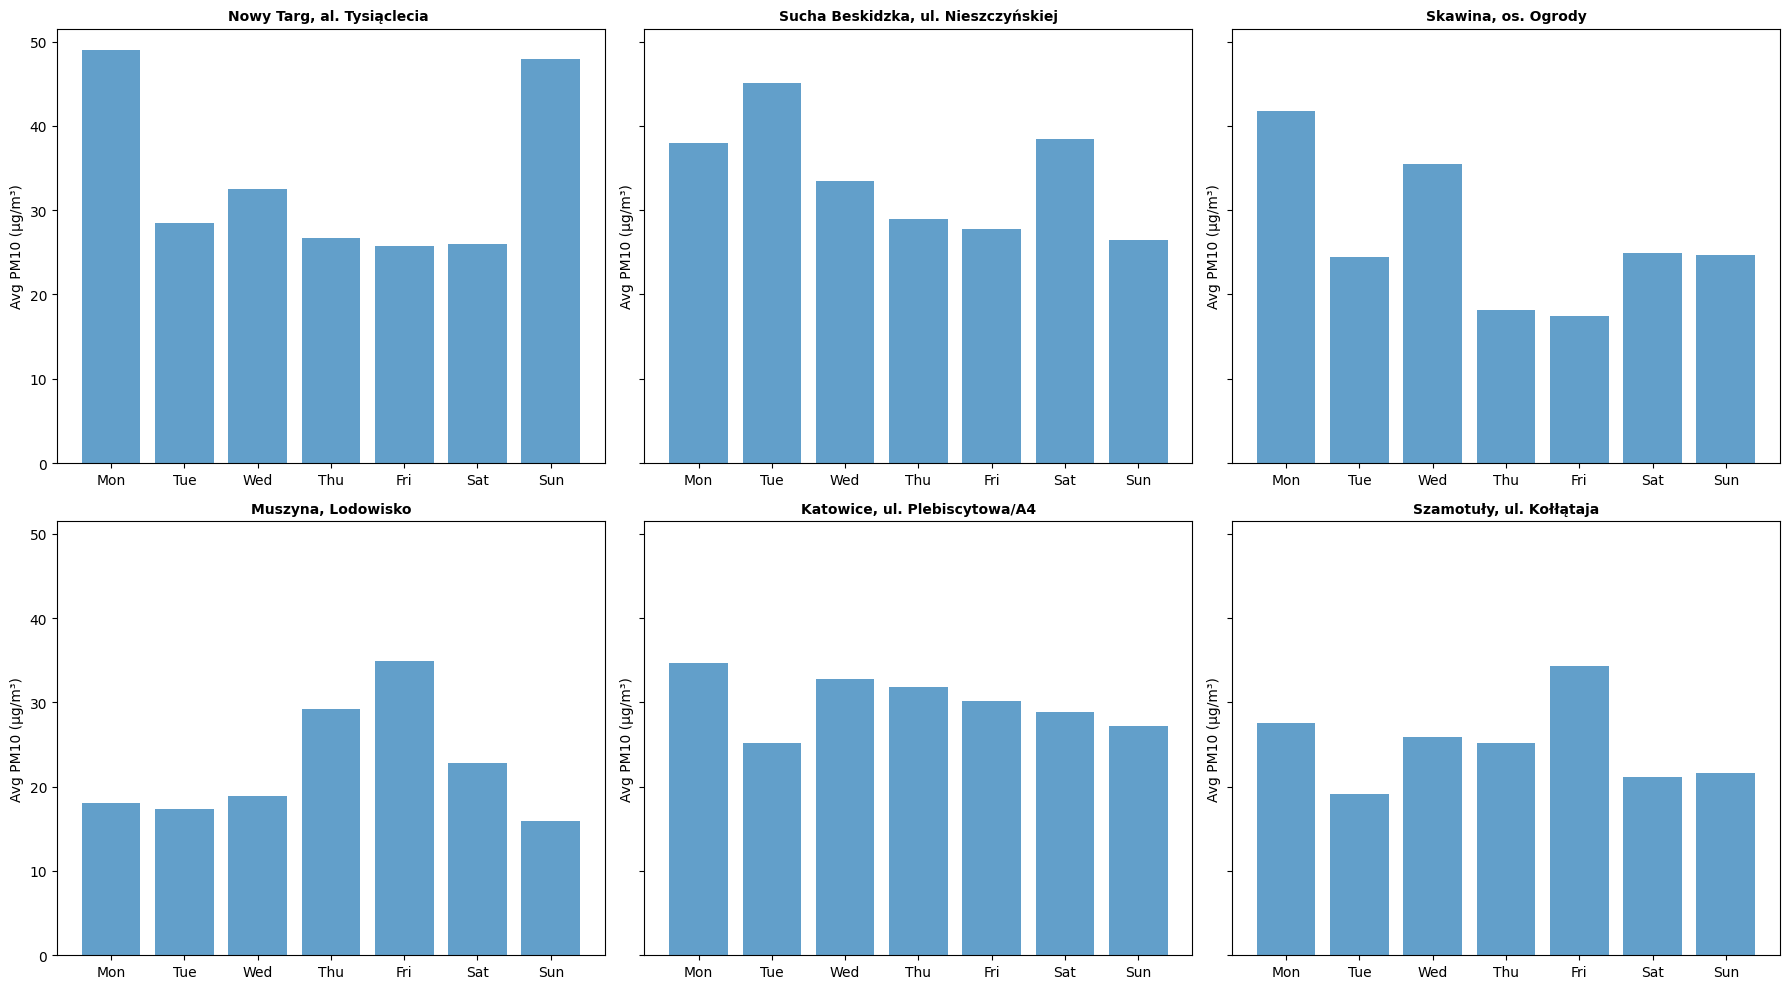

In [36]:
base_df = df_joined.filter((hour("datetime") >= 8) & (hour("datetime") <= 20)) \
                   .filter(col("parameter") == "pm10")

weekly_profile_df = base_df.groupBy("name", dayofweek("datetime").alias("dow")) \
                           .agg(avg("value").alias("avg_concentration"))

w = Window.partitionBy("name").orderBy(desc("avg_concentration"))
top_locs_rows = weekly_profile_df.withColumn("rank", row_number().over(w)) \
                                 .filter(col("rank") == 1) \
                                 .orderBy(desc("avg_concentration")) \
                                 .limit(6) \
                                 .select("name") \
                                 .collect()

top_6_names = [row['name'] for row in top_locs_rows]

plot_data_df = weekly_profile_df.filter(col("name").isin(top_6_names))
pdf = plot_data_df.toPandas()

dow_map = {1: 'Sun', 2: 'Mon', 3: 'Tue', 4: 'Wed', 5: 'Thu', 6: 'Fri', 7: 'Sat'}
order = [2, 3, 4, 5, 6, 7, 1]
order_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.clf()
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.flatten()

print(f"Plotting weekly profiles for: {top_6_names}")

for i, loc_name in enumerate(top_6_names):
    loc_data = pdf[pdf['name'] == loc_name].set_index('dow')
    loc_data = loc_data.reindex(order).fillna(0)
    ax = axes[i]
    ax.bar(order_names, loc_data['avg_concentration'], alpha=0.7)
    ax.set_title(loc_name, fontsize=10, fontweight='bold')
    ax.set_ylabel('Avg PM10 (µg/m³)')

plt.tight_layout()
plt.show()

### Zadanie 3

[1p] Wczytaj dane z trzech różnych krajów, po 5 lokalizacji dla każdego. Następnie stwórz zapytanie, które dla każdego kraju wyznacza top 3 lokalizacji z największym średnim stężeniem PM10

In [39]:
target_countries = ['DE', 'FR', 'GB']
target_year = "2023"
target_months = ["01", "02", "03"]

target_ids = []
for c in target_countries:
    rows = locations_df.filter(col("country_code") == c) \
                       .filter(col("datetimeLast.utc") >= f"{target_year}-01-01") \
                       .select("id") \
                       .limit(5) \
                       .collect()
    target_ids.extend([r.id for r in rows])

valid_paths = []
sc = spark.sparkContext
fs = sc._jvm.org.apache.hadoop.fs.FileSystem.get(
    sc._jvm.java.net.URI("s3a://openaq-data-archive/"),
    sc._jsc.hadoopConfiguration()
)
Path = sc._jvm.org.apache.hadoop.fs.Path

for lid in target_ids:
    for m in target_months:
        p = f"s3a://openaq-data-archive/records/csv.gz/locationid={lid}/year={target_year}/month={m}/"
        try:
            if fs.exists(Path(p)):
                valid_paths.append(p)
        except:
            pass

df_3 = spark.read.option("header", "true") \
             .option("basePath", "s3a://openaq-data-archive/records/csv.gz/") \
             .csv(valid_paths)

df_3 = df_3.withColumn("value", col("value").cast("double"))

df_joined_3 = df_3.join(locations_df, df_3.locationid == locations_df.id)

pm10_df = df_joined_3.filter(col("parameter") == "pm10")

avg_df = pm10_df.groupBy("country_code", "name") \
                .agg(avg("value").alias("avg_pm10"))

w_country = Window.partitionBy("country_code").orderBy(desc("avg_pm10"))

result_task3 = avg_df.withColumn("rank", row_number().over(w_country)) \
                     .filter(col("rank") <= 3) \
                     .select(col("country_code").alias("Country"), "rank", "name", "avg_pm10") \
                     .orderBy("Country", "rank")

result_task3.show(truncate=False)

+-------+----+----------------------------------+------------------+
|Country|rank|name                              |avg_pm10          |
+-------+----+----------------------------------+------------------+
|DE     |1   |München/Stachus                   |30.787216494845378|
|DE     |2   |Stuttgart-Bad Cannstatt           |22.24023668639053 |
|DE     |3   |Hagen Graf-von-Galen-Ring         |19.940329601990037|
|FR     |1   |Chambéry Trafic                   |16.544930417495035|
|FR     |2   |SAINT ETIENNE SUD                 |13.425968436154951|
|FR     |3   |Valence Périurb. Sud              |12.875809199318567|
|GB     |1   |Southwark - A2 Old Kent Road FIDAS|22.48128712871289 |
|GB     |2   |London Harlington - UKA00472      |15.34748427672956 |
|GB     |3   |Harrow - Stanmore                 |13.234828496042216|
+-------+----+----------------------------------+------------------+



### Zadanie 4

[1p] Stwórz zapytanie, które wypisuje lokalizacje, dla których średnie dzienne stężenie parametru **p** przekroczyło wartość **w** przez więcej niż **n** dni w badanym okresie.

In [41]:
from pyspark.sql.functions import col, to_date, avg, count, desc

p = "pm10"
w = 40.0
n = 4

daily_avg = df_joined.filter(col("parameter") == p) \
                     .withColumn("date", to_date("datetime")) \
                     .groupBy("name", "date") \
                     .agg(avg("value").alias("daily_val"))

bad_days = daily_avg.filter(col("daily_val") > w)

task4_result = bad_days.groupBy("name") \
                       .agg(count("date").alias("days_exceeded")) \
                       .filter(col("days_exceeded") > n) \
                       .orderBy(desc("days_exceeded"))

task4_result.show(truncate=False)

+------------------------------------+-------------+
|name                                |days_exceeded|
+------------------------------------+-------------+
|Nowy Targ, al. Tysiąclecia          |15           |
|Sucha Beskidzka, ul. Nieszczyńskiej |13           |
|Katowice, ul. Plebiscytowa/A4       |9            |
|Vernovice-Dolni Lutyne              |8            |
|Olkusz, ul. Cegielniana             |8            |
|Rzeszów, ul. Starzyńskiego          |7            |
|Ostróda, ul. Piłsudskiego           |7            |
|Gajew, Ujęcie Wody                  |7            |
|Bielsko-Biała, ul. Kossak-Szczuckiej|7            |
|Połaniec, ul. Ruszczańska           |6            |
|Kraków, os. Swoszowice              |6            |
|Brzeg, ul. Poprzeczna               |6            |
|Muszyna, Lodowisko                  |6            |
|Skawina, os. Ogrody                 |5            |
+------------------------------------+-------------+



## Big Data Cluster Queries

In [45]:
workers = np.arange(1, 8)
times = np.array([1060, 373, 209, 184, 137, 131, 105])
speedups = times[0] / times
efficiencies = speedups / workers

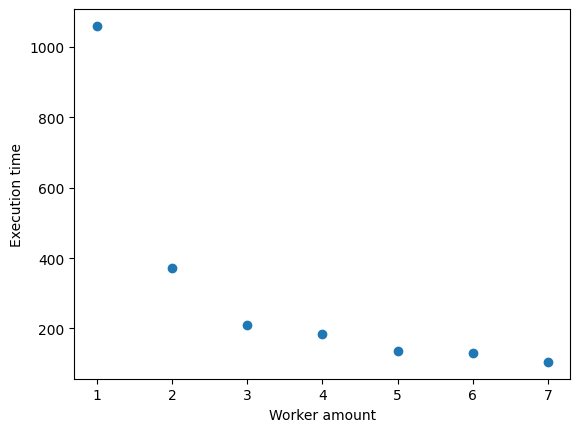

In [51]:
plt.clf()
plt.scatter(workers, times)
plt.xlabel("Worker amount")
plt.ylabel("Execution time")
plt.show()

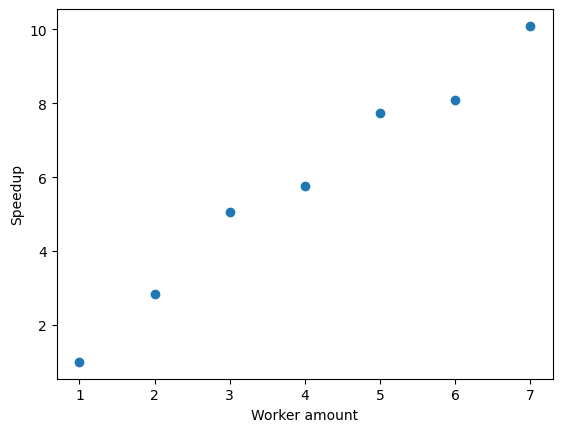

In [50]:
plt.clf()
plt.scatter(workers, speedups)
plt.xlabel("Worker amount")
plt.ylabel("Speedup")
plt.show()

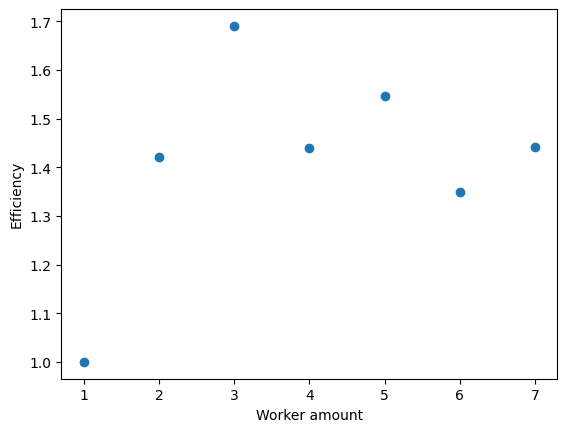

In [52]:
plt.clf()
plt.scatter(workers, efficiencies)
plt.xlabel("Worker amount")
plt.ylabel("Efficiency")
plt.show()